--- Primeiras linhas do dataset ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

--- Informações Gerais do Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  f

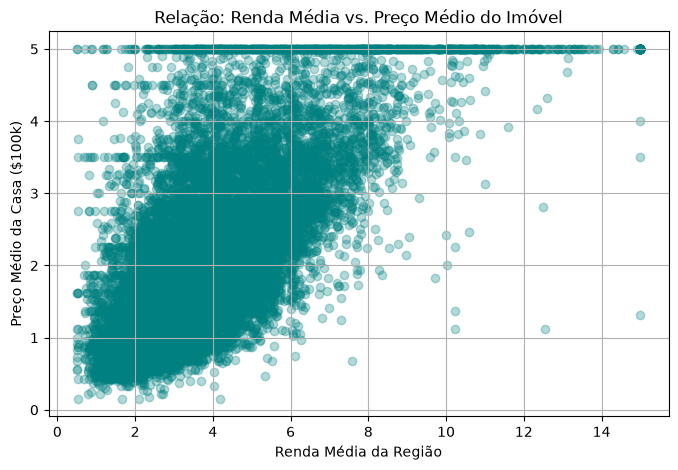

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# 1. Baixar a base de dados oficial de casas da Califórnia
california = fetch_california_housing(as_frame=True)
df = california.frame

# 2. Visualizar as primeiras 5 linhas da tabela para entender os dados
print("--- Primeiras linhas do dataset ---")
print(df.head())

# 3. Ver informações sobre colunas e tipos de dados (limpeza de dados)
print("\n--- Informações Gerais do Dataset ---")
df.info()

# 4. Criar um gráfico simples: Relação entre a Renda Média e o Preço da Casa
plt.figure(figsize=(8, 5))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.3, color='teal')
plt.title('Relação: Renda Média vs. Preço Médio do Imóvel')
plt.xlabel('Renda Média da Região')
plt.ylabel('Preço Médio da Casa ($100k)')
plt.grid(True)
plt.show()

In [3]:
# 1. Importar as ferramentas de Machine Learning do scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Vamos carregar os dados de forma organizada (garantindo que as variáveis existam nesta célula)
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing(as_frame=True)
df = california.frame

# 2. Definir quem é a nossa entrada (X) e nosso alvo de previsão (y)
# Vamos usar a renda média ('MedInc') para prever o preço médio da casa ('MedHouseVal')
X = df[['MedInc']] 
y = df['MedHouseVal']

# 3. Dividir os dados em "Treino" e "Teste"
# O modelo estuda com os dados de treino (80%) e nós o avaliamos com os dados de teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Criar e treinar o Modelo de Regressão Linear
modelo = LinearRegression()
modelo.fit(X_train, y_train) # É aqui que o "aprendizado" acontece!

# 5. Fazer previsões usando os dados de teste que o modelo nunca viu antes
previsoes = modelo.predict(X_test)

# 6. Avaliar o quão bom é o nosso modelo
erro_medio = mean_squared_error(y_test, previsoes)
r2 = r2_score(y_test, previsoes)

print("--- MODELO TREINADO COM SUCESSO ---")
print(f"Erro Quadrático Médio (MSE): {erro_medio:.4f}")
print(f"Poder de explicação do modelo (R²): {r2:.4f} (ou {r2*100:.1f}%)")

--- MODELO TREINADO COM SUCESSO ---
Erro Quadrático Médio (MSE): 0.7091
Poder de explicação do modelo (R²): 0.4589 (ou 45.9%)


In [4]:
# 1. Preparar os dados com múltiplas variáveis (X)
# Vamos usar todas as características disponíveis no dataset, exceto o preço alvo
X_multiplo = df.drop(columns=['MedHouseVal']) # Remove o preço das entradas
y_multiplo = df['MedHouseVal'] # O preço continua a ser o nosso alvo

# Vamos dar uma espreitadela nas colunas que o modelo vai analisar:
print("Variáveis que o modelo vai usar para prever:")
print(list(X_multiplo.columns))

# 2. Dividir em Treino (80%) e Teste (20%)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multiplo, y_multiplo, test_size=0.2, random_state=42
)

# 3. Criar e treinar o novo modelo múltiplo
modelo_multiplo = LinearRegression()
modelo_multiplo.fit(X_train_m, y_train_m)

# 4. Fazer previsões
previsoes_m = modelo_multiplo.predict(X_test_m)

# 5. Avaliar as novas métricas
erro_medio_m = mean_squared_error(y_test_m, previsoes_m)
r2_m = r2_score(y_test_m, previsoes_m)

print("\n--- NOVO MODELO (MÚLTIPLO) TREINADO ---")
print(f"Novo Erro Quadrático Médio (MSE): {erro_medio_m:.4f}")
print(f"Novo Poder de explicação (R²): {r2_m:.4f} (ou {r2_m*100:.1f}%)")

# 6. Comparação direta com o modelo anterior
print("\n--- COMPARAÇÃO ---")
print(f"R² Anterior (Simples): {r2*100:.1f}%")
print(f"R² Atual (Múltiplo): {r2_m*100:.1f}%")
print(f"Melhoria no R²: {(r2_m - r2)*100:.1f}% pontos percentuais!")

Variáveis que o modelo vai usar para prever:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

--- NOVO MODELO (MÚLTIPLO) TREINADO ---
Novo Erro Quadrático Médio (MSE): 0.5559
Novo Poder de explicação (R²): 0.5758 (ou 57.6%)

--- COMPARAÇÃO ---
R² Anterior (Simples): 45.9%
R² Atual (Múltiplo): 57.6%
Melhoria no R²: 11.7% pontos percentuais!
